# ScAdver PBMC Batch Correction (10x v2/v3)

Reference/query projection with **automatic routing** in `transform_query_adaptive`:
- probe threshold (`||Δ(z)|| > 0.1`)
- overlap/support gate (`shared_cell_ratio >= 0.8`, `shared_class_ratio >= 0.8`, enough cells per shared class)

This notebook trains on PBMC reference, projects PBMC query, saves corrected AnnData,
and visualizes final integration in UMAP.

In [1]:
import os

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import anndata as ad
import scanpy as sc
import torch
import matplotlib.pyplot as plt

import scadver
from scadver import (
    adversarial_batch_correction,
    transform_query_adaptive,
    save_model,
    load_model,
    set_global_seed,
)

SEED = 42
set_global_seed(SEED)

print('✅ Libraries imported')
print(f"   ScAdver : {scadver.__version__}")
print(f"   Scanpy  : {sc.__version__}")
print(f"   Torch   : {torch.__version__}")
print(f"   Device  : {'MPS' if torch.backends.mps.is_available() else 'CPU'}")

✅ Libraries imported
   ScAdver : 2.0
   Scanpy  : 1.11.4
   Torch   : 2.8.0
   Device  : MPS


## Step 1 — Build mixed-assay split (5000 reference / 3000 query)

In [2]:
_HERE = os.getcwd()
if not os.path.exists(os.path.join(_HERE, '10x_v2_pbmc.h5ad')):
    maybe_examples = os.path.join(_HERE, 'examples')
    if os.path.exists(os.path.join(maybe_examples, '10x_v2_pbmc.h5ad')):
        _HERE = maybe_examples

V2_PATH = os.path.join(_HERE, '10x_v2_pbmc.h5ad')
V3_PATH = os.path.join(_HERE, '10x_v3_pbmc.h5ad')

adata_v2 = ad.read_h5ad(V2_PATH, backed='r')
adata_v3 = ad.read_h5ad(V3_PATH, backed='r')
common_genes = adata_v2.var_names.intersection(adata_v3.var_names)

# class: (ref_v2, ref_v3, query_v2, query_v3)
quota = {
    'B cell':                             (840, 360, 160, 640),
    'natural killer cell':                (1190, 510, 200, 800),
    'conventional dendritic cell':        (630, 270, 120, 480),
    'plasmacytoid dendritic cell':        (385, 165, 70, 280),
    'plasmablast':                        (245, 105, 40, 160),
    'CD4-positive, alpha-beta T cell':    (140, 60, 6, 24),
    'CD8-positive, alpha-beta T cell':    (70, 30, 4, 16),
}

v2_labels = adata_v2.obs['cell_type'].astype(str).to_numpy()
v3_labels = adata_v3.obs['cell_type'].astype(str).to_numpy()
rng = np.random.default_rng(SEED)

ref_idx_v2, ref_idx_v3, query_idx_v2, query_idx_v3 = [], [], [], []
for ct, (rv2, rv3, qv2, qv3) in quota.items():
    idx_v2 = np.flatnonzero(v2_labels == ct)
    idx_v3 = np.flatnonzero(v3_labels == ct)
    pick_v2 = rng.choice(idx_v2, size=(rv2 + qv2), replace=False)
    pick_v3 = rng.choice(idx_v3, size=(rv3 + qv3), replace=False)

    ref_idx_v2.extend(pick_v2[:rv2].tolist())
    query_idx_v2.extend(pick_v2[rv2:].tolist())
    ref_idx_v3.extend(pick_v3[:rv3].tolist())
    query_idx_v3.extend(pick_v3[rv3:].tolist())

adata_ref_v2 = adata_v2[np.sort(np.asarray(ref_idx_v2, dtype=np.int64)), common_genes].to_memory()
adata_ref_v3 = adata_v3[np.sort(np.asarray(ref_idx_v3, dtype=np.int64)), common_genes].to_memory()
adata_query_v2 = adata_v2[np.sort(np.asarray(query_idx_v2, dtype=np.int64)), common_genes].to_memory()
adata_query_v3 = adata_v3[np.sort(np.asarray(query_idx_v3, dtype=np.int64)), common_genes].to_memory()

adata_ref_v2.obs['source'] = 'reference'
adata_ref_v3.obs['source'] = 'reference'
adata_query_v2.obs['source'] = 'query'
adata_query_v3.obs['source'] = 'query'

adata_all = ad.concat([adata_ref_v2, adata_ref_v3, adata_query_v2, adata_query_v3], join='inner', merge='same')
adata_all.obs_names_make_unique()

sample_probe = adata_all.X[: min(128, adata_all.n_obs)]
if hasattr(sample_probe, 'toarray'):
    sample_probe = sample_probe.toarray()
if float(np.max(np.asarray(sample_probe))) > 50:
    sc.pp.normalize_total(adata_all, target_sum=1e4)
    sc.pp.log1p(adata_all)

sc.pp.highly_variable_genes(adata_all, n_top_genes=min(2000, adata_all.n_vars), flavor='seurat', batch_key='assay')
adata_all = adata_all[:, adata_all.var['highly_variable']].copy()

adata_ref = adata_all[adata_all.obs['source'] == 'reference'].copy()
adata_query = adata_all[adata_all.obs['source'] == 'query'].copy()

bio_label = 'cell_type'
batch_label = 'assay'

print('Constructed split:')
print(f'  Reference cells: {adata_ref.n_obs}')
print(f'  Query cells    : {adata_query.n_obs}')
print(f'  HVGs           : {adata_ref.n_vars}')
print()
print('Reference assay counts:')
print(adata_ref.obs[batch_label].value_counts().to_string())
print()
print('Query assay counts:')
print(adata_query.obs[batch_label].value_counts().to_string())

Constructed split:
  Reference cells: 5000
  Query cells    : 3000
  HVGs           : 2000

Reference assay counts:
assay
10x 3' v2    3500
10x 3' v3    1500

Query assay counts:
assay
10x 3' v3    2400
10x 3' v2     600


## Step 2 — Train ScAdver on reference

In [3]:
%%time
adata_ref_corrected, model, ref_metrics = adversarial_batch_correction(
    adata=adata_ref,
    bio_label=bio_label,
    batch_label=batch_label,
    latent_dim=256,
    epochs=300,
    learning_rate=0.001,
    batch_weight=0.5,
    device='auto',
    return_reconstructed=True,
    calculate_metrics=False,
    seed=SEED,
)

print()
print('✅ Reference training complete')
print(f"   Embedding shape: {adata_ref_corrected.obsm['X_ScAdver'].shape}")

 ADVERSARIAL BATCH CORRECTION
   Device: mps
 DATA PREPARATION:
   Valid samples: 5000/5000
   Input shape: (5000, 2000)
   Biology labels: 7 unique
   Batch labels: 2 unique
     bio_weight='auto' → 20.00 (for 7 classes)
 MODEL ARCHITECTURE:
   Input dimension: 2000
   Latent dimension: 256
   Biology classes: 7
   Batch classes: 2


 TRAINING MODEL:
   Epochs: 300
   Learning rate: 0.001
   Effective bio weight: 20.00
   Batch weight: 0.5
   Batch size (adaptive): 128 (39 batches/epoch for 5,000 samples)


   Epoch 60/300 - Bio accuracy (Reference): 0.996 (best: 0.996)


   Epoch 120/300 - Bio accuracy (Reference): 0.975 (best: 0.996)


   Epoch 180/300 - Bio accuracy (Reference): 0.974 (best: 0.996)


   Epoch 240/300 - Bio accuracy (Reference): 0.999 (best: 0.999)


   Epoch 300/300 - Bio accuracy (Reference): 1.000 (best: 1.000)
 Training completed! Best monitored biology accuracy: 1.000
 GENERATING CORRECTED EMBEDDING:
   Output embedding shape: (5000, 256)
   Reconstructed expression shape: (5000, 2000)
    Batch-corrected gene expression saved to adata.layers['ScAdver_reconstructed']
 ADVERSARIAL BATCH CORRECTION COMPLETE!
   Latent embedding: adata_corrected.obsm['X_ScAdver'] (shape: (5000, 256))
   Reconstructed expression: adata_corrected.layers['ScAdver_reconstructed'] (shape: (5000, 2000))

✅ Reference training complete
   Embedding shape: (5000, 256)
CPU times: user 3min 56s, sys: 26.6 s, total: 4min 22s
Wall time: 4min


## Step 3 — Save reference model (for future query projection)

In [ ]:
model_out = os.path.join(_HERE, 'scadver_pbmc_ref.pt')
save_model(model, model_out)
print(f'Saved reference model: {model_out}')

# Optional check: load it back
#model = load_model(model_out, map_location='cpu')
#print('Reload check passed')

## Step 4 — Adaptive query projection (auto routing)

In [5]:
%%time
adata_query_corrected = transform_query_adaptive(
    model=model,
    adata_query=adata_query,
    adata_reference=adata_ref,
    bio_label=bio_label,
    adaptation_epochs=120,
    warmup_epochs=30,
    patience=30,
    max_epochs=220,
    learning_rate=0.0007,
    alignment_mode='auto',
    device='auto',
    return_reconstructed=True,
    seed=SEED,
)

print()
print('✅ Query projection complete')
print(f"   Query embedding shape: {adata_query_corrected.obsm['X_ScAdver'].shape}")

 PATH SELECTION...
   Reference classes: 7 | Probe samples: 1000


    Residual Probe Analysis:
      norm(Δ(z)): 0.9635  (std 1.5173)
      Metric    : same-class balanced-neighbor distance (assay)
      Shared cells : 100.0%
      Shared labels: 100.0%
      Shared count : 7
      Min ref cells/shared class   : 100
      Min query cells/shared class : 20
    Decision: ADAPTER NEEDED
      Confidence: HIGH
    norm(Δ(z)) > 0.1: raw source shift detected — adapting query toward the reference manifold
    Adapter mode: neighbor


 ADAPTIVE QUERY PROJECTION (Enhanced)
   Device: mps
   Query samples: 3000


   Reference samples for alignment: 5000
   Bio label      : cell_type
   Query classes  : 7
   Ref classifier : 7 output classes
   Shared classes : 7/7
   Shared cells   : 100.0%
   Overlap ratio  : 100.0%
    Bio supervision ENABLED  — weight = 2.0 (7 classes)
   Conditional alignment: 7 cell types indexed
   Prototype anchors  : 7 class centroids

 NEIGHBOR RESIDUAL MODE: Same-class reference neighborhood pull
   Strong shared bio-label coverage with enough matched cells per class → deterministic local residual correction


   Raw same-class shift  : 0.7242
   Matched query cells   : 100.0%
   Balanced targets      : same-class neighbors averaged across assay
   Applied alpha         : 0.25
    Reconstructed expression: (3000, 2000)
    Returning neighborhood residual projection

✅ Query projection complete
   Query embedding shape: (3000, 256)
CPU times: user 1.02 s, sys: 1.86 s, total: 2.88 s
Wall time: 436 ms


## Step 5 — Save corrected AnnData

In [ ]:
ref_out = os.path.join(_HERE, 'adata_pbmc_ref_corrected.h5ad')
query_out = os.path.join(_HERE, 'adata_pbmc_query_corrected.h5ad')

adata_ref_corrected.write_h5ad(ref_out)
adata_query_corrected.write_h5ad(query_out)

print('Saved:')
print(' ', ref_out)
print(' ', query_out)

## Step 6 — Final UMAP

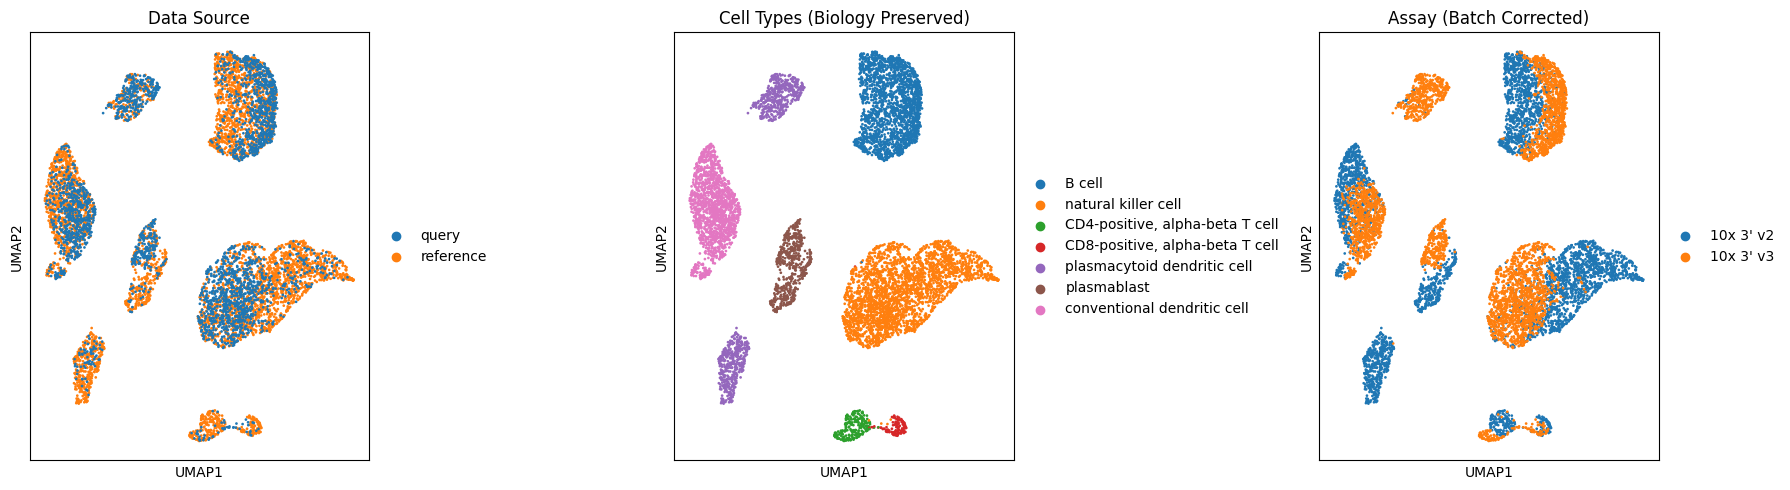

In [7]:
adata_ref_corrected.obs['source'] = 'reference'
adata_query_corrected.obs['source'] = 'query'

adata_ref_query_corrected = ad.concat([adata_ref_corrected, adata_query_corrected], join='inner', merge='same')
adata_ref_query_corrected.obs_names_make_unique()

sc.pp.neighbors(adata_ref_query_corrected, use_rep='X_ScAdver', n_neighbors=15)
sc.tl.umap(adata_ref_query_corrected, random_state=SEED)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sc.pl.umap(adata_ref_query_corrected, color='source', ax=axes[0], show=False, title='Data Source')
sc.pl.umap(adata_ref_query_corrected, color=bio_label, ax=axes[1], show=False, title='Cell Types (Biology Preserved)')
sc.pl.umap(adata_ref_query_corrected, color=batch_label, ax=axes[2], show=False, title='Assay (Batch Corrected)')
plt.tight_layout()
plt.show()

In [8]:
adata_ref_query_corrected

AnnData object with n_obs × n_vars = 8000 × 2000
    obs: 'assay_ontology_term_id', 'is_primary_data', 'cell_type_ontology_term_id', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'suspension_type', 'donor_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'sex_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'source'
    var: 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'neighbors', 'umap', 'source_colors', 'cell_type_colors', 'assay_colors'
    obsm: 'X_pca', 'X_umap', 'X_ScAdver'
    layers: 'ScAdver_reconstructed'
    obsp: 'distances', 'connectivities'

In [9]:
# For downstream analysis, you can use the reconstructed data (if returned) or the original data with the new embedding.
adata_downstream = adata_ref_query_corrected.copy()
adata_downstream.X = adata_downstream.layers['ScAdver_reconstructed'].copy()